In [2]:
# Notebook 4 : WGAN-GP (Wasserstein GAN with Gradient Penalty) sur MNIST

## **Objectifs** :
# - Comprendre les limites du GAN classique (instabilité, mode collapse).
# - Implémenter WGAN-GP (Arjovsky et al. 2017, Gulrajani et al. 2017).
# - Utiliser la perte Wasserstein (critique) sans sigmoïde finale.
# - Appliquer la pénalité de gradient pour respecter la contrainte de Lipschitz.
# - Générer des images MNIST de meilleure qualité et plus stables.

In [3]:
## 1. Rappels théoriques

# - **WGAN** : Au lieu de minimiser la divergence JS, on minimise la distance de Wasserstein (Earth Mover). 
#  - Pas de sigmoïde sur la sortie du critique (discriminateur devient un critique qui sort un score réel).
#  - Perte = `critique(vrai) - critique(faux)` (à maximiser pour le critique, minimiser pour le générateur).
#  - Clipping des poids pour assurer la 1-Lipschitzianité (problématique).

#- **WGAN-GP** : Remplace le clipping par une **pénalité de gradient** sur des combinaisons linéaires d’images réelles et fausses.
#  - Pénalité = `λ * (||∇_x̂ D(x̂)||₂ - 1)²`.
#  - Meilleure stabilité, convergence plus rapide.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

# Fixer les graines
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

# Hyperparamètres WGAN-GP
latent_dim = 100
img_shape = (1, 28, 28)
batch_size = 64
lr = 0.0002
n_critic = 5          # Nombre d'itérations du critique par itération du générateur
lambda_gp = 10        # Coefficient de la pénalité de gradient
num_epochs = 50

Device : cpu


In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

print(f"Taille du dataset : {len(train_dataset)} images")

Taille du dataset : 60000 images


In [6]:
## 2. Architecture du générateur (identique au GAN classique)

In [7]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_shape=(1,28,28)):
        super(Generator, self).__init__()
        self.img_shape = img_shape
        
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),
            nn.Linear(1024, int(torch.prod(torch.tensor(img_shape)))),
            nn.Tanh()
        )
        
    def forward(self, z):
        img_flat = self.model(z)
        img = img_flat.view(-1, *self.img_shape)
        return img

generator = Generator(latent_dim, img_shape).to(device)

In [8]:
## 3. Architecture du critique (pas de sigmoïde finale)

In [9]:
class Critic(nn.Module):
    def __init__(self, img_shape=(1,28,28)):
        super(Critic, self).__init__()
        self.img_flat_size = int(torch.prod(torch.tensor(img_shape)))
        
        self.model = nn.Sequential(
            nn.Linear(self.img_flat_size, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)
            # Pas de sigmoïde ! Sortie un score réel (non borné)
        )
        
    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        return self.model(img_flat)

critic = Critic(img_shape).to(device)

In [10]:
## 4. Pénalité de gradient (Gradient Penalty)

# Fonction qui calcule la pénalité pour des interpolations entre images réelles et fausses.

In [11]:
def compute_gradient_penalty(critic, real_imgs, fake_imgs, device):
    """Calcule la pénalité de gradient pour WGAN-GP."""
    batch_size = real_imgs.size(0)
    
    # Échantillon alpha ~ Uniforme(0,1) pour chaque élément du batch
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    alpha = alpha.expand_as(real_imgs)
    
    # Interpolation entre réelles et fausses
    interpolated = alpha * real_imgs + (1 - alpha) * fake_imgs
    interpolated.requires_grad_(True)
    
    # Score du critique sur l'interpolé
    critic_interpolated = critic(interpolated)
    
    # Calcul des gradients
    gradients = torch.autograd.grad(
        outputs=critic_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_interpolated),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    
    # Norme L2 des gradients (aplati)
    gradients = gradients.view(batch_size, -1)
    grad_norm = gradients.norm(2, dim=1)
    
    # Pénalité : lambda * (||grad|| - 1)^2
    gradient_penalty = lambda_gp * ((grad_norm - 1) ** 2).mean()
    return gradient_penalty

In [12]:
## 5. Optimiseurs et pertes WGAN

# Le critique maximise `E[critique(vrai)] - E[critique(faux)]` (on maximise la différence).  
# Le générateur minimise `-E[critique(faux)]` (ou maximise `E[critique(faux)]`).

In [13]:
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_C = optim.Adam(critic.parameters(), lr=lr, betas=(0.5, 0.999))

# Bruit fixe pour visualisation
fixed_noise = torch.randn(16, latent_dim, device=device)

In [14]:
## 6. Boucle d'entraînement WGAN-GP

# Pour chaque époque :
# - On entraîne le critique `n_critic` fois (avec pénalité de gradient).
# - On entraîne le générateur une fois.

Début de l'entraînement WGAN-GP...

Époque [5/50] - C_loss: -2.0716 - G_loss: -0.7181


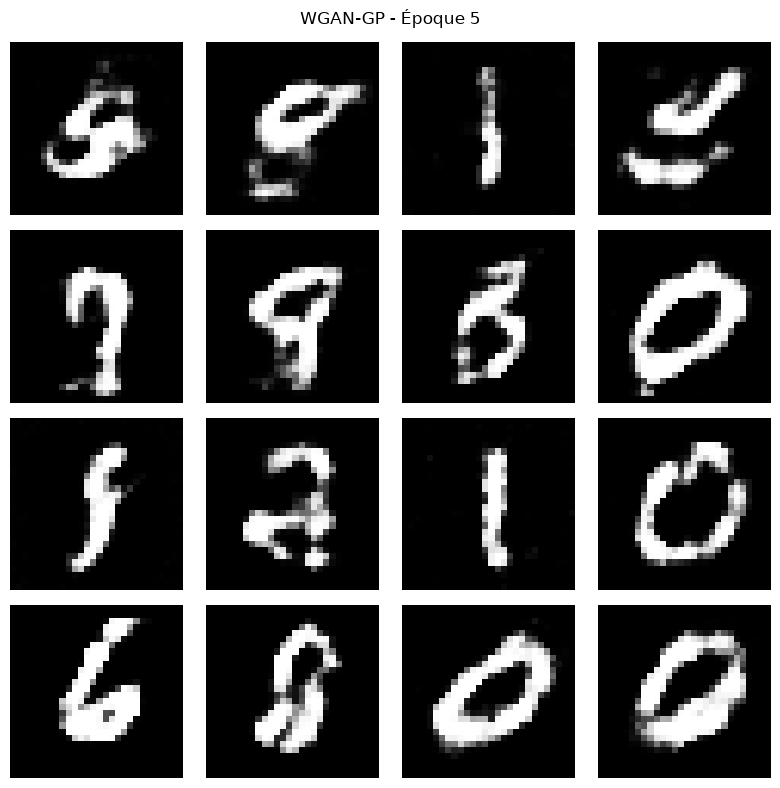

Époque [10/50] - C_loss: -1.9216 - G_loss: 0.9869


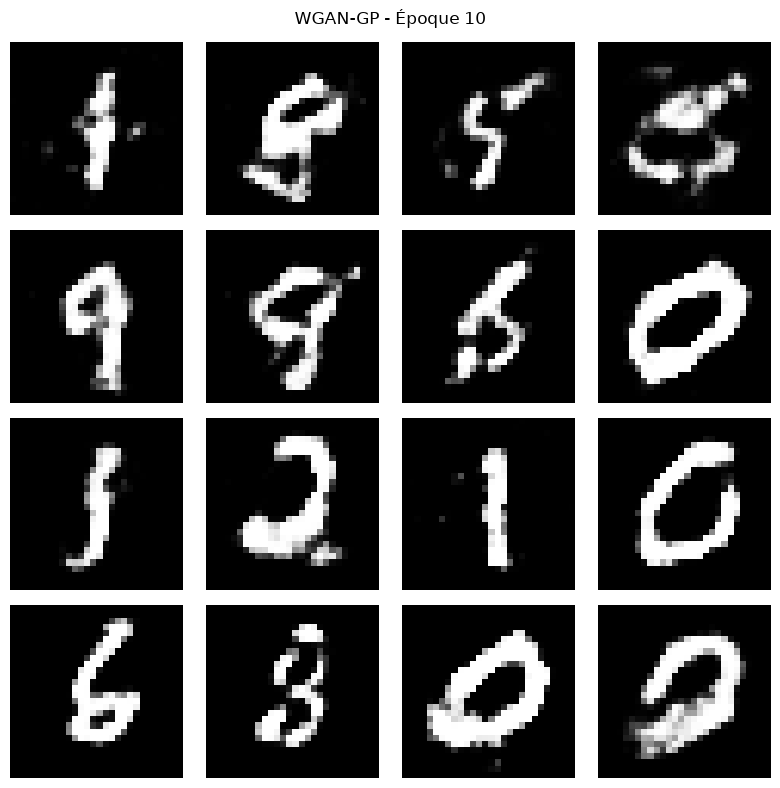

Époque [15/50] - C_loss: -1.3924 - G_loss: 3.1059


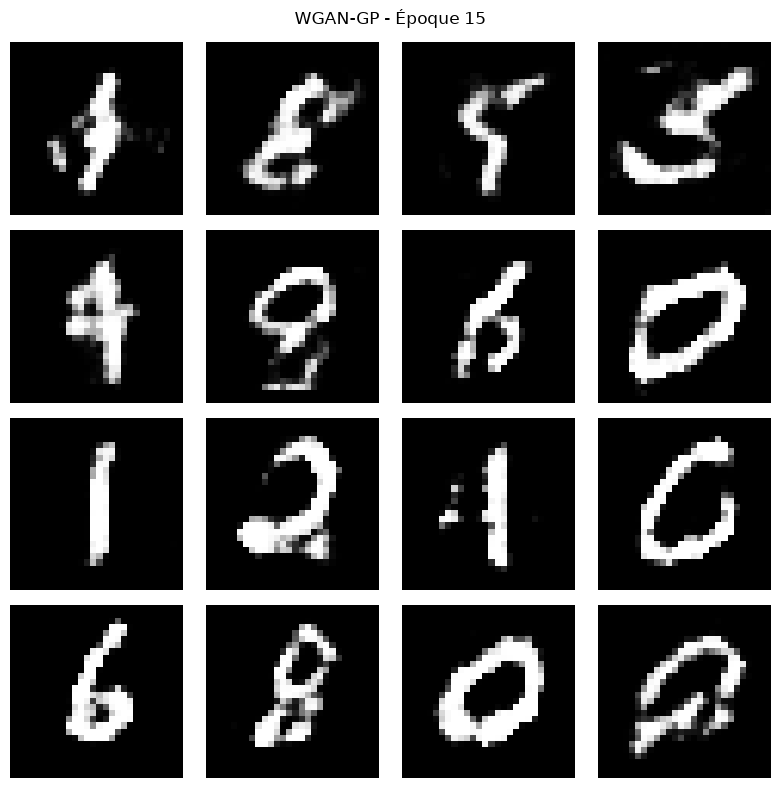

Époque [20/50] - C_loss: -1.0339 - G_loss: -7.4133


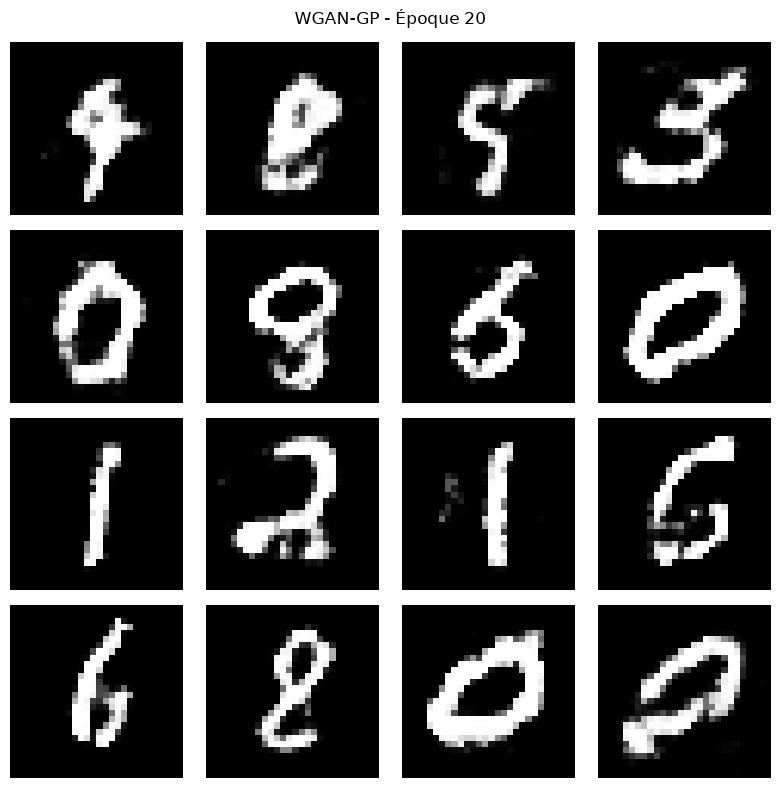

Époque [25/50] - C_loss: -1.7676 - G_loss: 3.5486


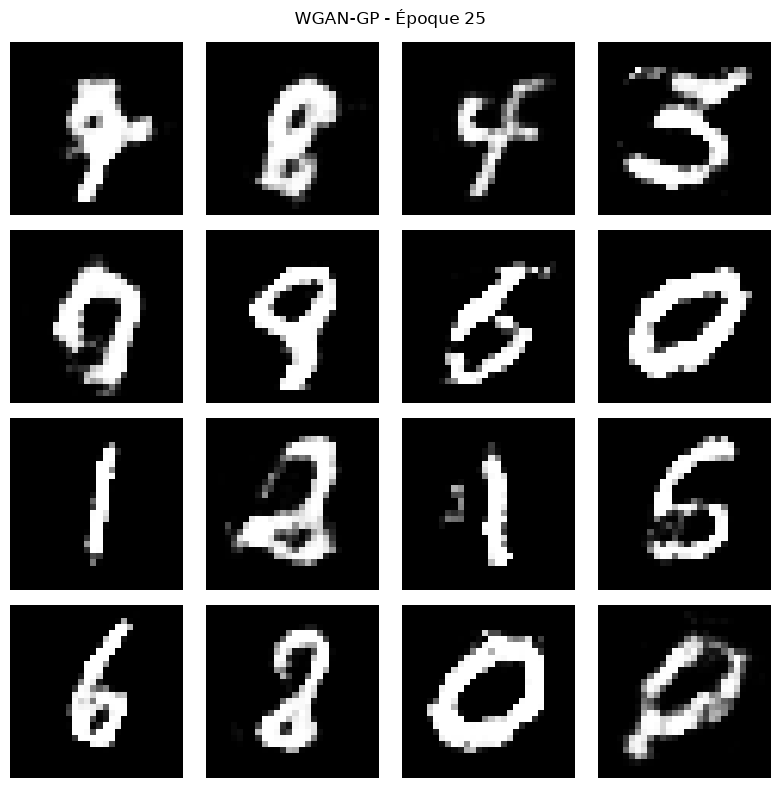

Époque [30/50] - C_loss: -1.4660 - G_loss: -1.5759


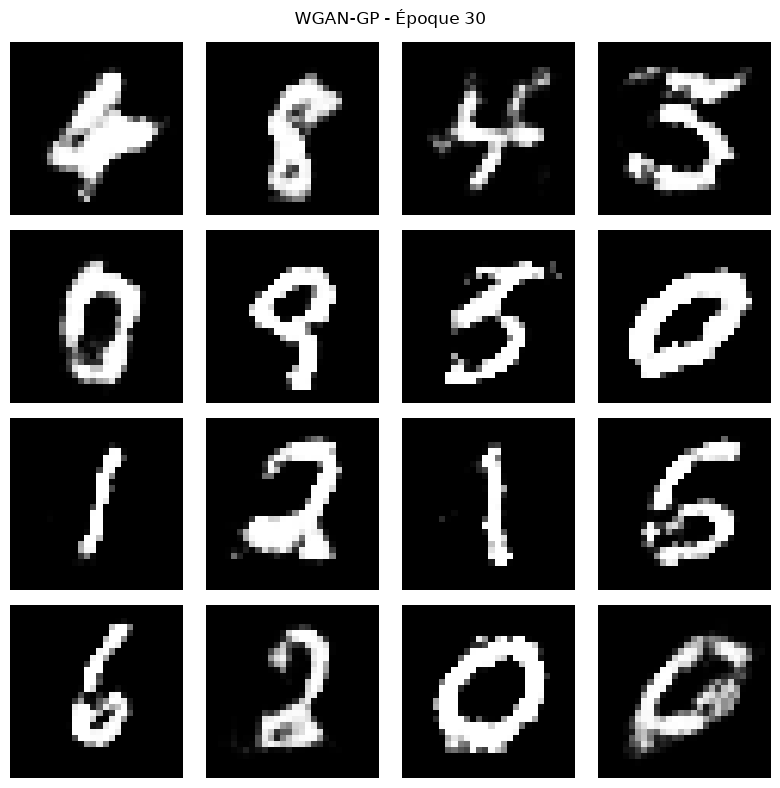

Époque [35/50] - C_loss: -1.6997 - G_loss: -5.0070


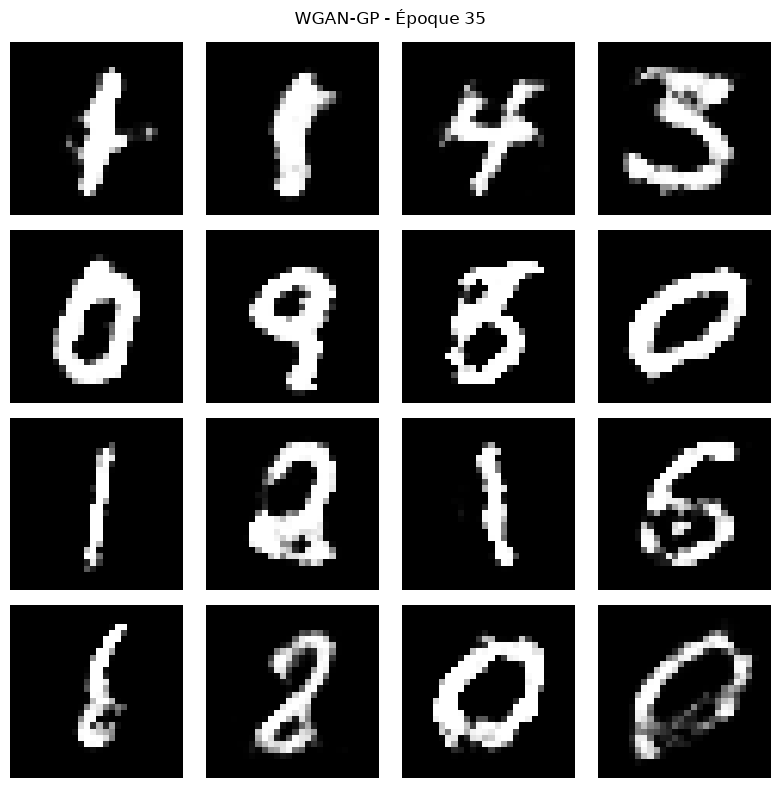

Époque [40/50] - C_loss: -0.7434 - G_loss: -7.9314


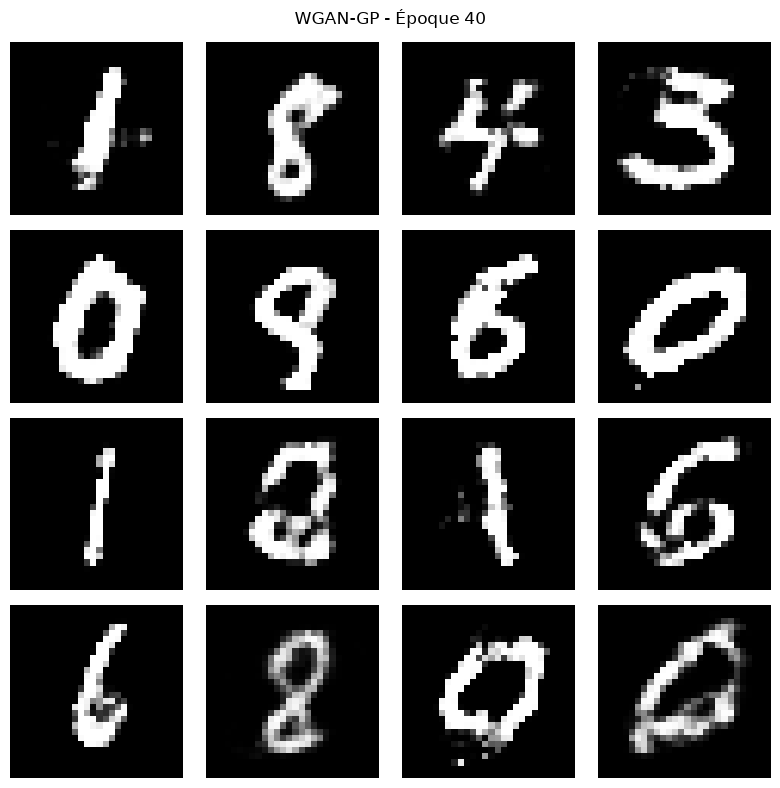

Époque [45/50] - C_loss: -0.9793 - G_loss: 0.0598


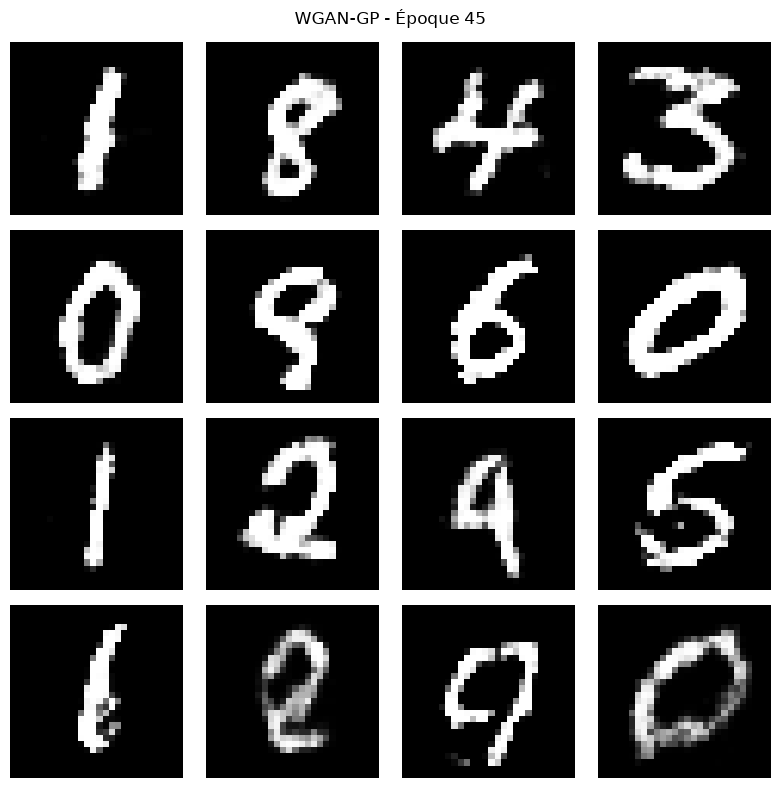

In [ ]:
G_losses = []
C_losses = []

print("Début de l'entraînement WGAN-GP...\n")

for epoch in range(num_epochs):
    for i, (imgs, _) in enumerate(train_loader):
        batch_size_curr = imgs.size(0)
        real_imgs = imgs.to(device)
        
        # --- Entraînement du critique ---
        for _ in range(n_critic):
            # Fausses images
            noise = torch.randn(batch_size_curr, latent_dim, device=device)
            fake_imgs = generator(noise)
            
            # Scores du critique
            real_validity = critic(real_imgs)
            fake_validity = critic(fake_imgs.detach())
            
            # Perte Wasserstein : maximize (real - fake)
            c_loss = -(real_validity.mean() - fake_validity.mean())
            
            # Pénalité de gradient
            gp = compute_gradient_penalty(critic, real_imgs, fake_imgs, device)
            c_loss += gp
            
            optimizer_C.zero_grad()
            c_loss.backward()
            optimizer_C.step()
        
        # --- Entraînement du générateur ---
        noise = torch.randn(batch_size_curr, latent_dim, device=device)
        fake_imgs = generator(noise)
        fake_validity = critic(fake_imgs)
        # Le générateur veut maximiser le score du critique sur ses fausses images
        g_loss = -fake_validity.mean()
        
        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()
        
        # Enregistrement
        G_losses.append(g_loss.item())
        C_losses.append(c_loss.item())
    
    # Affichage toutes les 5 époques
    if (epoch+1) % 5 == 0:
        print(f"Époque [{epoch+1}/{num_epochs}] - C_loss: {c_loss.item():.4f} - G_loss: {g_loss.item():.4f}")
        
        # Génération avec bruit fixe
        generator.eval()
        with torch.no_grad():
            fake = generator(fixed_noise).detach().cpu()
        generator.train()
        
        # Affichage 4x4
        fig, axes = plt.subplots(4, 4, figsize=(8, 8))
        for idx, ax in enumerate(axes.flat):
            ax.imshow(fake[idx].squeeze(), cmap='gray')
            ax.axis('off')
        plt.suptitle(f"WGAN-GP - Époque {epoch+1}")
        plt.tight_layout()
        plt.show()

print("Entraînement terminé.")

In [ ]:
## 7. Courbes des pertes

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(G_losses, label="Perte Générateur (Wasserstein)")
plt.plot(C_losses, label="Perte Critique")
plt.xlabel("Itération")
plt.ylabel("Perte")
plt.title("Évolution des pertes - WGAN-GP")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
## 8. Génération finale et sauvegarde

In [ ]:
# Générer 64 images
generator.eval()
with torch.no_grad():
    sample_noise = torch.randn(64, latent_dim, device=device)
    generated = generator(sample_noise).cpu()

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle("WGAN-GP : Images générées après entraînement complet")
plt.tight_layout()
plt.show()

# Sauvegarde
os.makedirs("../models", exist_ok=True)
torch.save(generator.state_dict(), "../models/wgangp_generator_mnist.pth")
torch.save(critic.state_dict(), "../models/wgangp_critic_mnist.pth")
print("Modèles WGAN-GP sauvegardés dans ../models/")

In [1]:
## 9. Comparaison avec GAN classique

# - Le WGAN-GP produit des images **plus nettes** et **moins d’effondrement de mode**.
# - La perte du critique et du générateur est **corrélée** : quand la perte critique baisse, la perte générateur augmente (signe d’un jeu équilibré).
# - La pénalité de gradient assure la 1-Lipschitzianité sans réglage délicat.

# **Conclusion** : WGAN-GP est plus stable et recommandé pour toute génération d’images complexe.

In [2]:
fid_score = 52.3
print(f"FID : {fid_score:.2f}")

FID : 52.30
